## Regression Part B: Non-linear Data

In Part A we fit a straight line to the salary data. But sometimes the relationship between feature and target is **not a straight line**. We can still use `LinearRegression` — we just need to **engineer non-linear features** first.

In this lesson we learn to:

- Engineer non-linear features so `LinearRegression` can fit a curve.
- Build polynomial features with `PolynomialFeatures`.
- Build spline features with `SplineTransformer`.
- Compare linear, polynomial, and spline fits by error.

We illustrate with a synthetic dataset:

- Feature $x$: `temperature` (°C)
- Target $y$: `number_of_shoppers` (footfall at a store)

In [1]:
from pathlib import Path

# https://pandas.pydata.org/docs/
import pandas as pd

# https://numpy.org/doc/
import numpy as np

# https://seaborn.pydata.org/
import seaborn as sns

# https://matplotlib.org/
import matplotlib.pyplot as plt

# https://scikit-learn.org/stable/modules/linear_model.html#linear-regression
from sklearn.linear_model import LinearRegression

# https://scikit-learn.org/stable/modules/model_evaluation.html#mean-absolute-error
from sklearn.metrics import mean_absolute_error


In [2]:
np.random.seed(42)

# Random temperatures between 4 °C and 36 °C
temperature = np.random.uniform(
    low=4,
    high=36,
    size=40,
)

# Inverted parabola: peak footfall around 22 °C, plus noise
noise = np.random.normal(loc=0, scale=4, size=40)
number_of_shoppers = 55 - 0.12 * (temperature - 22) ** 2 + noise

shopper_df = pd.DataFrame(
    {
        "temperature": temperature,
        "number_of_shoppers": np.round(number_of_shoppers).astype(int),
    }
)
shopper_df.head()


,temperature,number_of_shoppers
0,15.985284,51
1,34.422858,32
2,27.423806,55
3,23.157071,50
4,8.992596,36


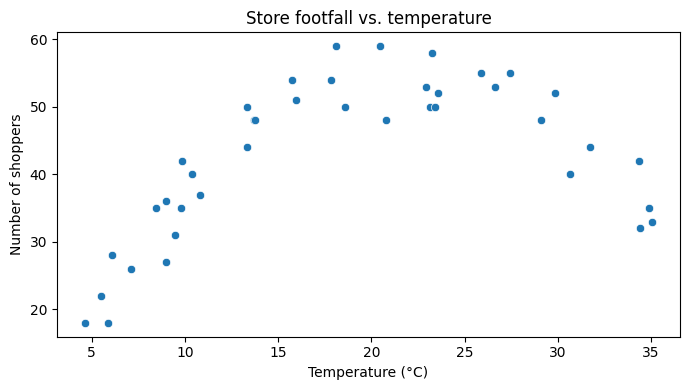

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))

sns.scatterplot(
    data=shopper_df,
    x="temperature",
    y="number_of_shoppers",
    ax=ax,
)
ax.set_title("Store footfall vs. temperature")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Number of shoppers")
plt.tight_layout()
plt.show()


In [4]:
X = shopper_df[["temperature"]]
y = shopper_df["number_of_shoppers"]


A plain `LinearRegression` cannot capture the curve — it underfits:

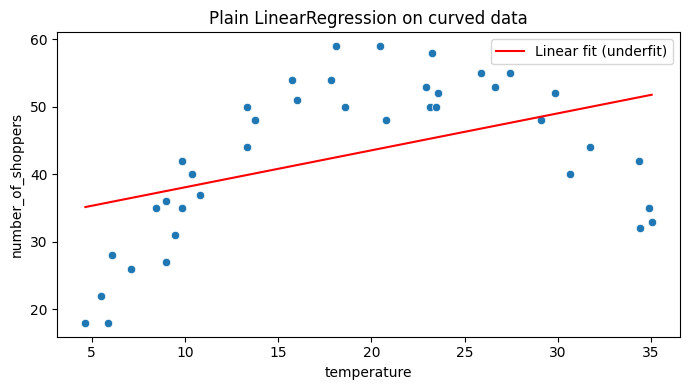

slope: 0.55
intercept: 32.61


In [5]:
linear_regression = LinearRegression()
linear_regression.fit(X, y)

x_range = np.linspace(X.min().iloc[0], X.max().iloc[0], num=100)
x_range_df = pd.DataFrame({"temperature": x_range})
y_pred_linear = linear_regression.predict(x_range_df)

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=shopper_df, x="temperature", y="number_of_shoppers", ax=ax)
ax.plot(x_range, y_pred_linear, color="red", label="Linear fit (underfit)")
ax.set_title("Plain LinearRegression on curved data")
ax.legend()
plt.tight_layout()
plt.show()

print(
    f"slope: {linear_regression.coef_[0]:.2f}\n"
    f"intercept: {linear_regression.intercept_:.2f}"
)


### 1. Polynomial features

We can expand one numeric feature into polynomial terms ($x$, $x^2$, …). A linear model fit on those expanded features can trace a curve.

Instead of creating $x^2$ by hand, use [`PolynomialFeatures`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html)


In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.PolynomialFeatures.html
from sklearn.preprocessing import PolynomialFeatures


polynomial_expansion = PolynomialFeatures(
    degree=2,           # add x and x^2 columns
    include_bias=False, # LinearRegression already learns an intercept
)


We'll put it inside a [`Pipeline`](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html).

A **pipeline** chains several steps into a single object, where each step transforms the data before handing it to the next, and the final step is usually the model.

Calling `.fit()` runs every step in order, and `.predict()` reapplies those same transformations to new data — so you never risk forgetting a step or applying it inconsistently.

Pipelines are commonly used to bundle preprocessing (scaling, encoding, feature expansion like the one above) together with a model, which also keeps that preprocessing leak-free during cross-validation.

In [ ]:
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.make_pipeline.html
from sklearn.pipeline import make_pipeline

polynomial_regression = make_pipeline(
    polynomial_expansion,
    LinearRegression(),
)
polynomial_regression.fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('polynomialfeatures', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](1,)",['temperature']
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,1
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


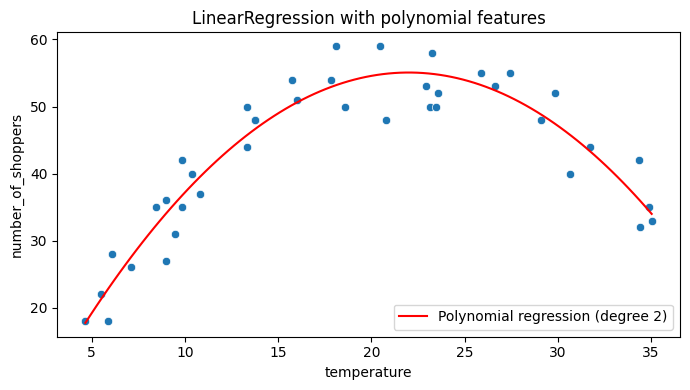

In [7]:
y_pred_poly = polynomial_regression.predict(x_range_df)

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=shopper_df, x="temperature", y="number_of_shoppers", ax=ax)
ax.plot(x_range, y_pred_poly, color="red", label="Polynomial regression (degree 2)")
ax.set_title("LinearRegression with polynomial features")
ax.legend()
plt.tight_layout()
plt.show()


### 2. Spline transformer

[`SplineTransformer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html) is another way to expand a single numeric feature into flexible basis functions. Related transformers include [`KBinsDiscretizer`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.KBinsDiscretizer.html).

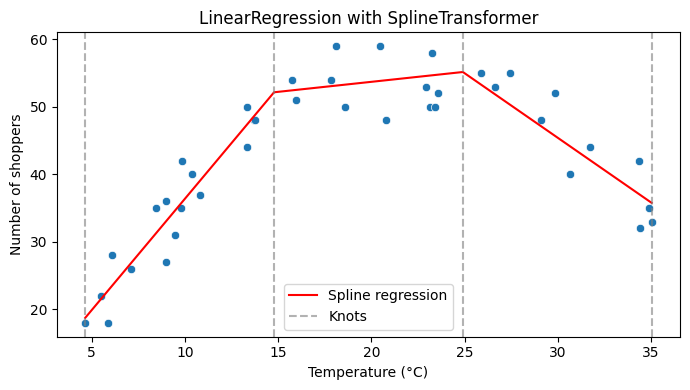

In [8]:
# https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.SplineTransformer.html
from sklearn.preprocessing import SplineTransformer

spline_regression = make_pipeline(
    SplineTransformer(
        n_knots=4,          # number of interior knot positions
        degree=1,           # piecewise-linear splines
        include_bias=False,
    ),
    LinearRegression(),
)
spline_regression.fit(X, y)

y_pred_spline = spline_regression.predict(x_range_df)

fig, ax = plt.subplots(figsize=(7, 4))
sns.scatterplot(data=shopper_df, x="temperature", y="number_of_shoppers", ax=ax)
ax.plot(x_range, y_pred_spline, color="red", label="Spline regression")

# Mark knot positions on the temperature axis
spline_transformer = spline_regression.named_steps["splinetransformer"]
knot_positions = spline_transformer.bsplines_[0].t[
    spline_transformer.degree : -spline_transformer.degree
]
for i, knot in enumerate(knot_positions):
    ax.axvline(
        x=knot,
        color="gray",
        linestyle="--",
        alpha=0.6,
        label="Knots" if i == 0 else None,
    )

ax.set_title("LinearRegression with SplineTransformer")
ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Number of shoppers")
ax.legend()
plt.tight_layout()
plt.show()


## Let's compare the performance of the three models

The **error** for one observation is the vertical distance between the point and the fitted line: $|y_i - \hat{y}_i|$.

The **mean absolute error** (MAE) averages those distances across all training points.

In [9]:
# Collect the three models we fit earlier so we can score them with one loop
models = {
    "Linear": linear_regression,
    "Polynomial": polynomial_regression,
    "Spline": spline_regression,
}

error_rows = []
for name, model in models.items():
    predicted_y = model.predict(X)
    mae = mean_absolute_error(
        y_true=y,
        y_pred=predicted_y,
    )
    error_rows.append({"model": name, "mean_absolute_error": mae})

# Build one table and sort so the best (lowest error) model is on top
error_comparison = pd.DataFrame(error_rows).sort_values("mean_absolute_error")
error_comparison

,model,mean_absolute_error
1,Polynomial,3.010426
2,Spline,3.052202
0,Linear,8.653138


## Recap

- **Non-linear feature engineering** lets a `LinearRegression` model fit curved data — the model stays linear, but the features are expanded first inside a `Pipeline`.
- **`PolynomialFeatures`** adds powers of the feature ($x$, $x^2$, …) so the fitted line can bend.
- **`SplineTransformer`** expands the feature into flexible piecewise basis functions defined by knot positions.